<h1>Импорт библиотек

In [10]:
import numpy as np
import matplotlib.pyplot as plt

<h1>Задача 1. Дан набор из $p$ матриц размерностью $(n, n)$ и $p$ векторов размерностью $(n, 1)$, найти сумму произведений матриц на векторы. Написать тесты для кода

In [11]:
def sum_prod(X, V):
    '''
    X - матрицы (n, n)
    V - векторы (n, 1)
    Гарантируется, что len(X) == len(V)
    '''
    result = np.zeros_like(X[0] @ V[0])
    for A, v in zip(X, V):
        result = result + A @ v
    return result

# Тесты
X = [np.array([[1, 0], [0, 1]]), np.array([[2, 0], [0, 2]])]
V = [np.array([[1], [2]]), np.array([[3], [4]])]
# E*[1,2] + 2E*[3,4] = [1,2] + [6,8] = [7,10]
assert np.allclose(sum_prod(X, V), [[7], [10]])

X2 = [np.eye(3)]
V2 = [np.array([[1], [2], [3]])]
assert np.allclose(sum_prod(X2, V2), [[1], [2], [3]])

print("Задача 1: все тесты пройдены")
print("sum_prod(X, V) =\n", sum_prod(X, V))

Задача 1: все тесты пройдены
sum_prod(X, V) =
 [[ 7]
 [10]]


<h1>Задача 2. Дана матрица M, напишите функцию, которая бинаризует матрицу по некоторому threshold (то есть, все значения большие threshold становятся равными 1, иначе 0). Напишите тесты для кода

In [12]:
def binarize(M, threshold=0.5):
    """Бинаризация матрицы: 1 если значение > threshold, иначе 0."""
    return (M > threshold).astype(int)

# Тесты
M = np.array([[0.1, 0.6], [0.4, 0.9]])
assert np.array_equal(binarize(M), [[0, 1], [0, 1]])
assert np.array_equal(binarize(M, 0.3), [[0, 1], [1, 1]])
assert np.array_equal(binarize(np.array([[0.5, 0.5]]), 0.5), [[0, 0]])  # > строго

print("Задача 2: все тесты пройдены")
print("binarize(M) =\n", binarize(M))

Задача 2: все тесты пройдены
binarize(M) =
 [[0 1]
 [0 1]]


<h1>Задача 3. Напишите функцию, которая возвращает уникальные элементы из каждой строки матрицы. Напишите такую же функцию, но для столбцов. Напишите тесты для кода

In [13]:
def unique_rows(mat):
    """Уникальные элементы каждой строки матрицы (список массивов)."""
    return [np.unique(row) for row in mat]

def unique_columns(mat):
    """Уникальные элементы каждого столбца матрицы (список массивов)."""
    return [np.unique(mat[:, j]) for j in range(mat.shape[1])]

# Тесты
M = np.array([[1, 2, 2, 3],
              [4, 4, 5, 6],
              [7, 8, 7, 9]])

r = unique_rows(M)
assert np.array_equal(r[0], [1, 2, 3])
assert np.array_equal(r[1], [4, 5, 6])
assert np.array_equal(r[2], [7, 8, 9])

c = unique_columns(M)
assert np.array_equal(c[0], [1, 4, 7])

print("Задача 3: все тесты пройдены")
print("unique_rows(M):", [list(x) for x in unique_rows(M)])
print("unique_columns(M):", [list(x) for x in unique_columns(M)])

Задача 3: все тесты пройдены
unique_rows(M): [[np.int64(1), np.int64(2), np.int64(3)], [np.int64(4), np.int64(5), np.int64(6)], [np.int64(7), np.int64(8), np.int64(9)]]
unique_columns(M): [[np.int64(1), np.int64(4), np.int64(7)], [np.int64(2), np.int64(4), np.int64(8)], [np.int64(2), np.int64(5), np.int64(7)], [np.int64(3), np.int64(6), np.int64(9)]]


<h1>Задача 4. Напишите функцию, которая заполняет матрицу с размерами $(m, n)$ случайными числами, распределенными по нормальному закону. Затем считает мат. ожидание и дисперсию для каждого из столбцов и строк, а также строит для каждой строки и столбца гистограмму значений (использовать функцию hist из модуля matplotlib.plot)

Матожидание по строкам:    [1.45  0.026 0.585]
Дисперсия по строкам:      [0.445 0.411 0.243]
Матожидание по столбцам:   [0.31  0.935 0.529 0.753 0.907]
Дисперсия по столбцам:     [1.266 0.185 0.24  1.115 0.461]


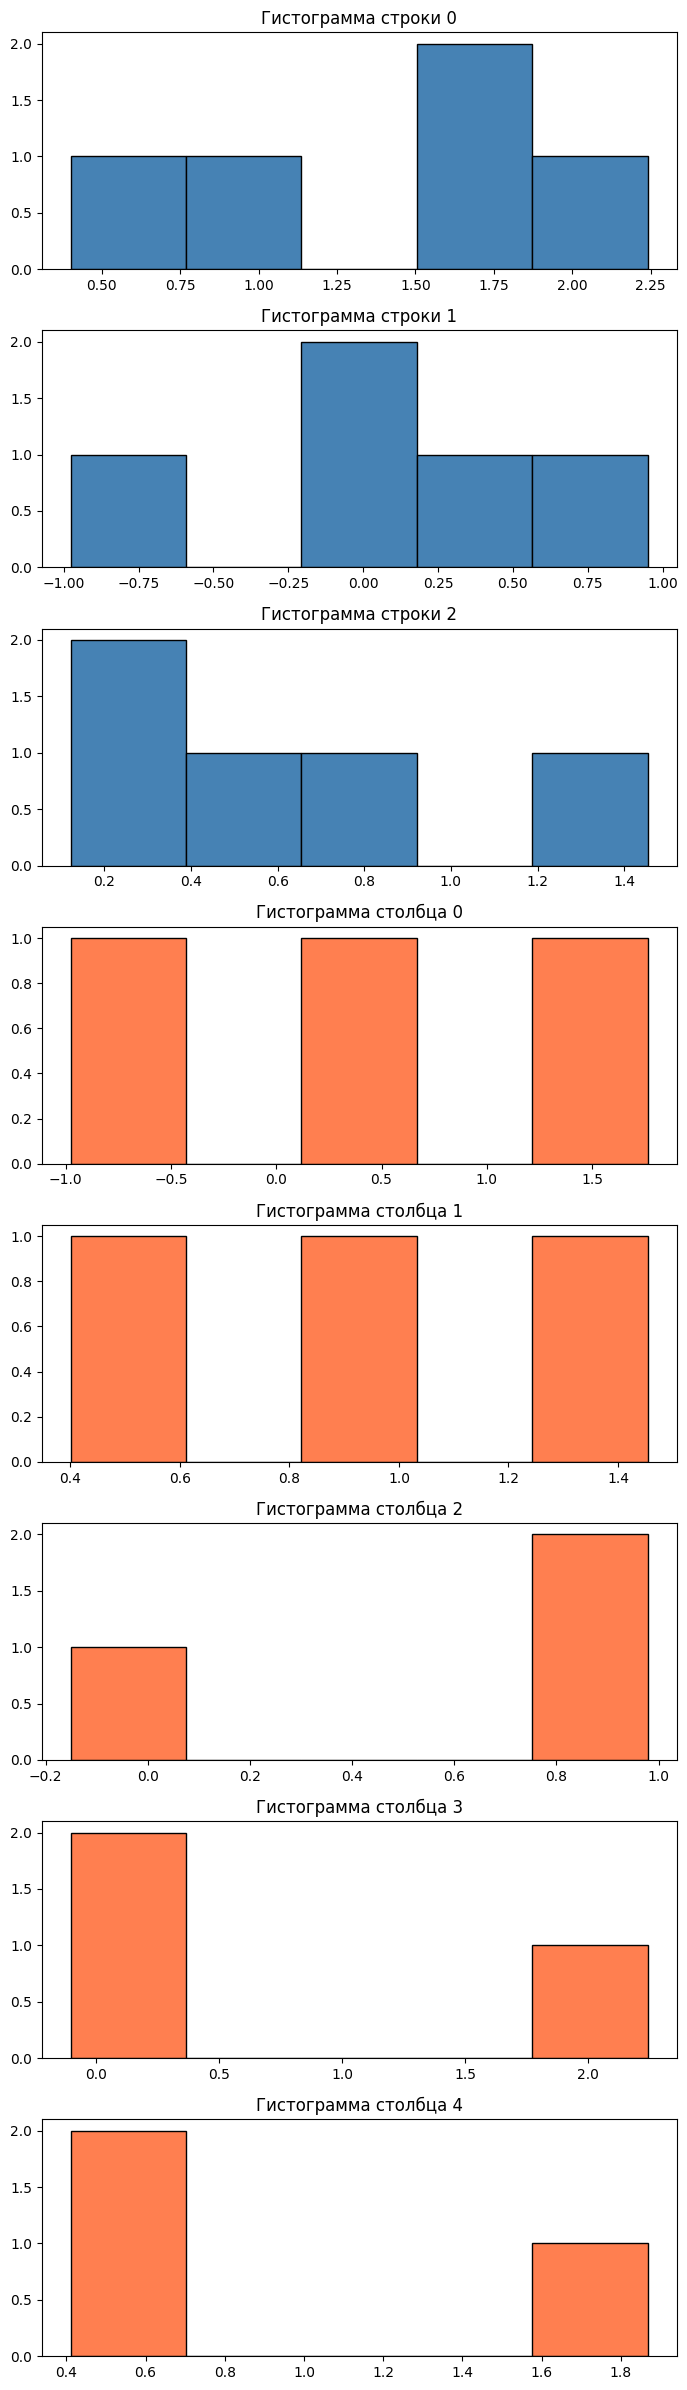

In [14]:
def normal_matrix_stats(m, n):
    """
    Заполняет матрицу (m, n) нормально распределёнными числами,
    выводит мат.ожидание и дисперсию по строкам и столбцам,
    строит гистограммы.
    """
    mat = np.random.randn(m, n)

    print("Матожидание по строкам:   ", np.mean(mat, axis=1).round(3))
    print("Дисперсия по строкам:     ", np.var(mat, axis=1).round(3))
    print("Матожидание по столбцам:  ", np.mean(mat, axis=0).round(3))
    print("Дисперсия по столбцам:    ", np.var(mat, axis=0).round(3))

    total = m + n
    fig, axes = plt.subplots(total, 1, figsize=(7, 3 * total))
    for i in range(m):
        axes[i].hist(mat[i], bins=max(5, n // 2), color='steelblue', edgecolor='black')
        axes[i].set_title(f'Гистограмма строки {i}')
    for j in range(n):
        axes[m + j].hist(mat[:, j], bins=max(5, m // 2), color='coral', edgecolor='black')
        axes[m + j].set_title(f'Гистограмма столбца {j}')
    plt.tight_layout()
    plt.show()
    return mat

np.random.seed(0)
mat = normal_matrix_stats(3, 5)

<h1>Задача 5. Напишите функцию, которая заполняет матрицу $(m, n)$ в шахматном порядке заданными числами $a$ и $b$. Напишите тесты для кода

In [15]:
def chess(m, n, a, b):
    """Матрица (m, n) в шахматном порядке из значений a и b."""
    idx = np.indices((m, n)).sum(axis=0) % 2
    # idx == 0 на "белых" клетках, == 1 на "чёрных"
    mat = np.where(idx == 0, a, b)
    return mat

# Тесты
res = chess(3, 3, 0, 1)
assert res[0, 0] == 0 and res[0, 1] == 1
assert res[1, 0] == 1 and res[1, 1] == 0

res2 = chess(2, 4, 0, 1)
assert np.array_equal(res2[0], [0, 1, 0, 1])
assert np.array_equal(res2[1], [1, 0, 1, 0])

print("Задача 5: все тесты пройдены")
print("chess(3, 3, 0, 1) =\n", chess(3, 3, 0, 1))
print("chess(4, 4, 'A', 'B') =\n", chess(4, 4, 'A', 'B'))

Задача 5: все тесты пройдены
chess(3, 3, 0, 1) =
 [[0 1 0]
 [1 0 1]
 [0 1 0]]
chess(4, 4, 'A', 'B') =
 [['A' 'B' 'A' 'B']
 ['B' 'A' 'B' 'A']
 ['A' 'B' 'A' 'B']
 ['B' 'A' 'B' 'A']]


<h1>Задача 6. Напишите функцию, которая отрисовывает прямоугольник с заданными размерами (a, b) на изображении размера (m, n), цвет фона задайте в схеме RGB, как и цвет прямоугольника. Цвета также должны быть параметрами функции. Напишите аналогичную функцию но для овала с полуосями a и b. Напишите тесты для кода.
Примечание: уравнение эллипса (границы овала) можно записать как:
<h1>$\frac{(x-x_0)^2}{a^2}+\frac{(y-y_0)^2}{b^2}=1$

Задача 6: все тесты пройдены


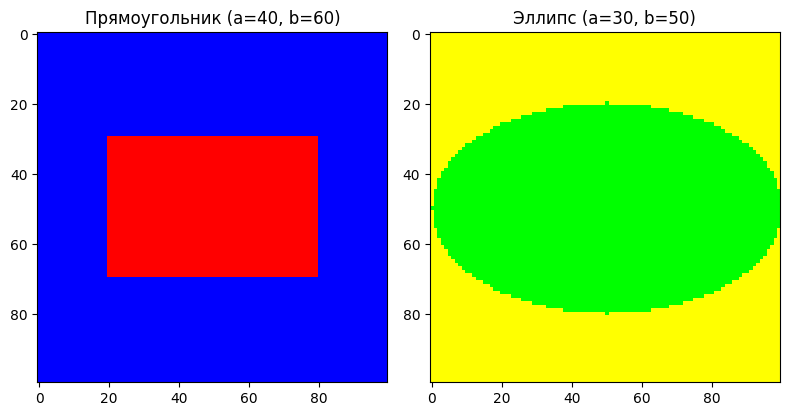

In [16]:
def draw_rectangle(a, b, m, n, rectangle_color, background_color):
    """
    Рисует прямоугольник (a x b пикселей) по центру изображения (m x n).
    rectangle_color, background_color — списки/кортежи [R, G, B].
    """
    img = np.full((m, n, 3), background_color, dtype=np.uint8)
    x0 = (m - a) // 2
    y0 = (n - b) // 2
    img[x0:x0 + a, y0:y0 + b] = rectangle_color
    return img

def draw_ellipse(a, b, m, n, ellipse_color, background_color):
    """
    Рисует эллипс с полуосями (a, b) по центру изображения (m x n).
    ellipse_color, background_color — списки/кортежи [R, G, B].
    """
    img = np.full((m, n, 3), background_color, dtype=np.uint8)
    cx, cy = m // 2, n // 2
    # Векторизованная маска через meshgrid
    ys, xs = np.ogrid[:m, :n]
    mask = ((xs - cy) ** 2 / b ** 2 + (ys - cx) ** 2 / a ** 2) <= 1
    img[mask] = ellipse_color
    return img

# Тесты
rect = draw_rectangle(40, 60, 100, 100, [255, 0, 0], [0, 0, 255])
assert rect.shape == (100, 100, 3)
assert list(rect[50, 50]) == [255, 0, 0]   # центр — красный
assert list(rect[0, 0]) == [0, 0, 255]     # угол — синий

ell = draw_ellipse(30, 50, 100, 100, [0, 255, 0], [255, 255, 0])
assert list(ell[50, 50]) == [0, 255, 0]    # центр — зелёный

print("Задача 6: все тесты пройдены")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(rect)
axes[0].set_title("Прямоугольник (a=40, b=60)")
axes[1].imshow(ell)
axes[1].set_title("Эллипс (a=30, b=50)")
plt.tight_layout()
plt.show()

<h1>Задача 7. Дан некий временной ряд. Для данного ряда нужно найти его: математическое ожидание, дисперсию, СКО, найти все локальные максимумы и минимумы (локальный максимум - это точка, которая больше своих соседних точек, а локальный минимум - это точка, которая меньше своих соседей), а также вычислить для данного ряда другой ряд, получаемый методом скользящего среднего с размером окна $p$.
<h1>Примечание: метод скользящего среднего подразумевает нахождение среднего из подмножетсва ряда размером $p$

Мат. ожидание: -6.405
Дисперсия:     21.351
СКО:           4.621
Локальных максимумов: 27
Локальных минимумов:  27


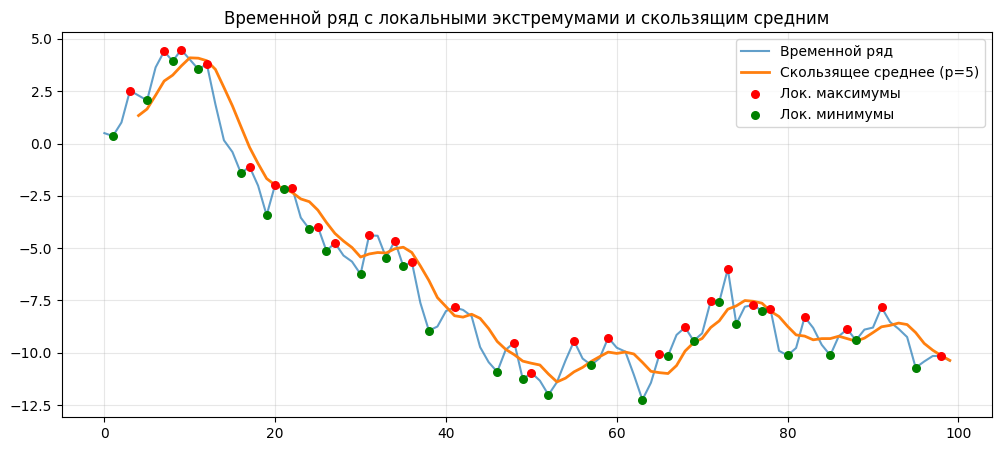

In [17]:
# Генерируем временной ряд
np.random.seed(42)
time_series = np.random.randn(100).cumsum()

# Статистики
mean_val = np.mean(time_series)
var_val  = np.var(time_series)
std_val  = np.std(time_series)

print(f"Мат. ожидание: {mean_val:.3f}")
print(f"Дисперсия:     {var_val:.3f}")
print(f"СКО:           {std_val:.3f}")

# Локальные максимумы и минимумы
local_max_idx = [i for i in range(1, len(time_series) - 1)
                 if time_series[i] > time_series[i - 1] and time_series[i] > time_series[i + 1]]
local_min_idx = [i for i in range(1, len(time_series) - 1)
                 if time_series[i] < time_series[i - 1] and time_series[i] < time_series[i + 1]]

print(f"Локальных максимумов: {len(local_max_idx)}")
print(f"Локальных минимумов:  {len(local_min_idx)}")

# Скользящее среднее
def moving_average(series, p):
    """Скользящее среднее с окном p."""
    return np.array([np.mean(series[i:i + p]) for i in range(len(series) - p + 1)])

p = 5
ma = moving_average(time_series, p)

# Визуализация
plt.figure(figsize=(12, 5))
plt.plot(time_series, label='Временной ряд', alpha=0.7)
plt.plot(range(p - 1, len(time_series)), ma, label=f'Скользящее среднее (p={p})', linewidth=2)
plt.scatter(local_max_idx, time_series[local_max_idx], color='red', zorder=5, label='Лок. максимумы', s=30)
plt.scatter(local_min_idx, time_series[local_min_idx], color='green', zorder=5, label='Лок. минимумы', s=30)
plt.legend()
plt.title('Временной ряд с локальными экстремумами и скользящим средним')
plt.grid(True, alpha=0.3)
plt.show()

<h1>Задача 8. Дан некоторый вектор с целочисленными метками классов, напишите функцию, которая выполняет one-hot-encoding для данного вектора
<h1>One-hot-encoding - представление, в котором на месте метки некоторого класса стоит 1, в остальных позициях стоит 0. Например для вектора [0, 2, 3, 0] one-hot-encoding выглядит как: [[1, 0, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1], [1, 0, 0, 0]]

In [18]:
def one_hot_encoding(labels):
    """
    One-hot-encoding вектора меток классов.
    labels — список или numpy-массив целых чисел (от 0 до max).
    Возвращает матрицу (len(labels), num_classes).
    """
    labels = np.array(labels)
    num_classes = labels.max() + 1
    result = np.zeros((len(labels), num_classes), dtype=int)
    result[np.arange(len(labels)), labels] = 1
    return result

# Тесты
res = one_hot_encoding([0, 2, 3, 0])
expected = np.array([[1, 0, 0, 0],
                     [0, 0, 1, 0],
                     [0, 0, 0, 1],
                     [1, 0, 0, 0]])
assert np.array_equal(res, expected)

res2 = one_hot_encoding([1, 0, 2])
assert np.array_equal(res2, [[0, 1, 0], [1, 0, 0], [0, 0, 1]])

print("Задача 8: все тесты пройдены")
print("one_hot_encoding([0, 2, 3, 0]) =\n", res)

Задача 8: все тесты пройдены
one_hot_encoding([0, 2, 3, 0]) =
 [[1 0 0 0]
 [0 0 1 0]
 [0 0 0 1]
 [1 0 0 0]]
